In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))
from db.database import Database
from util.dataframe_utils import get_dataframes
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
import os

# Set seeds for reproducibility
import random
import torch
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# Force deterministic behavior
os.environ['PYTHONHASHSEED'] = '42'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
db = Database()
bp_df, topics_df, posts_df = get_dataframes(db)
# Sort by id to ensure consistent row order
bp_df = bp_df.sort_values("id").reset_index(drop=True)
bp_df.head()

,id,blueprint_hash,name,extracted_keywords,blueprint_url,blueprint_code,post_id,description,keywords_yake,topic_id,tags,created_at
0,1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}",https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358
1,2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,"[""blueprint""]",2020-12-13 22:32:38.158
2,3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[""switch"", ""blueprint"", ""deconz""]",2020-12-15 12:18:15.898
3,4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414
4,5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519


In [3]:
import json, re
def process_bp_keywords(kwd_dict: dict[str, int] | str) -> list[str] | None:
    if isinstance(kwd_dict, str):
        kwd_dict = json.loads(kwd_dict)
    
    kwd_list = list(kwd_dict.keys())
    if kwd_list.__len__() < 1:
        return None
    
    kwds = []
    
    for kwd in kwd_list:
        in_out = re.search(r"(input__|output__)(input_|output_)?", kwd)
        kwd = kwd.removeprefix(in_out.group()) if in_out else kwd
        in_out = in_out.group(1) if in_out else None
        kwds.append(in_out + kwd if in_out else kwd)
    return kwds

In [4]:
from difflib import SequenceMatcher
def _normalize_feature_token(token: str) -> str:
    token = token.lower().strip()
    token = re.sub(r"[^a-z0-9]+", " ", token)
    token = re.sub(r"\s+", " ", token).strip()
    return token

def _similarity(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()

def normalize_yake_features(features: list[str], threshold: float = 0.88, min_len: int = 4) -> list[str]:
    """
    Canonicalize YAKE keywords using fuzzy matching and simple containment rules.
    Keeps original order but maps near-duplicates to a shared canonical token.
    """
    canonicals: list[str] = []
    canonical_map: dict[str, str] = {}
    for raw in features:
        norm = _normalize_feature_token(raw)
        if not norm:
            continue
        if norm in canonical_map:
            canonical = canonical_map[norm]
            canonicals.append(canonical)
            continue
        canonical = norm
        for existing in set(canonical_map.values()):
            if min(len(norm), len(existing)) >= min_len and (norm in existing or existing in norm):
                canonical = existing if len(existing) <= len(norm) else norm
                break
            if _similarity(norm, existing) >= threshold:
                canonical = existing
                break
        canonical_map[norm] = canonical
        canonicals.append(canonical)
    return canonicals

In [5]:
ignorable_tags = {"blueprint", "automation"}
bp_df["tags"] = bp_df["tags"].apply(lambda tags: [tag for tag in json.loads(tags) if tag not in ignorable_tags])
bp_df.head()

,id,blueprint_hash,name,extracted_keywords,blueprint_url,blueprint_code,post_id,description,keywords_yake,topic_id,tags,created_at
0,1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}",https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358
1,2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,[],2020-12-13 22:32:38.158
2,3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[switch, deconz]",2020-12-15 12:18:15.898
3,4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414
4,5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519


In [6]:
max_keywords = bp_df["extracted_keywords"].apply(lambda x: len(json.loads(x)) if isinstance(x, str) else 0).max() 
max_tags = bp_df["tags"].apply(lambda x: len(x) if isinstance(x, list) else 0).max()
max_yake = 4
max_features = max_keywords + max_tags + max_yake
max_keywords, max_tags, max_features

(15, 5, 24)

In [7]:
def extract_features(row, max_features=max_features):
    padding = "<PAD>"
    
    yake_features = json.loads(row["keywords_yake"])
    yake_features = normalize_yake_features(yake_features)
    combined_features = list(yake_features)
    ext_kw = process_bp_keywords(row["extracted_keywords"])
    if ext_kw:
        combined_features.extend(ext_kw)
    
    kw_n = max_keywords - len(ext_kw) if ext_kw else max_keywords
    combined_features += [padding] * kw_n
    
    tags = row["tags"]
    tag_n = max_tags - len(tags)
    combined_features.extend(tags)
    combined_features += [padding] * tag_n

    return combined_features

In [8]:
bp_df["features"] = bp_df.apply(extract_features, axis=1)
bp_df.head()

,id,blueprint_hash,name,extracted_keywords,blueprint_url,blueprint_code,post_id,description,keywords_yake,topic_id,tags,created_at,features
0,1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}",https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358,"[android notification, nag prompt, nag notific..."
1,2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,[],2020-12-13 22:32:38.158,"[fan, inovelli, create, dimmer, <PAD>, <PAD>, ..."
2,3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[switch, deconz]",2020-12-15 12:18:15.898,"[button short, button remote, long press, butt..."
3,4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414,"[set heating, heating temperature, time, set, ..."
4,5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519,"[light allowance, light, allowance, allotted, ..."


In [9]:
from sklearn.preprocessing import normalize
import pickle

# Apply the updated function
bp_df["features"] = bp_df.apply(lambda row: extract_features(row, max_features=15), axis=1)
bp_df["features"] = bp_df["features"].apply(lambda x: " ".join(x))

# Cache embeddings to file for reproducibility
cache_file = "output/embeddings_cache.pkl"
if os.path.exists(cache_file):
    print("Loading cached embeddings...")
    with open(cache_file, "rb") as f:
        cached_data = pickle.load(f)
        bp_df["embeddings"] = cached_data["embeddings"]
        X = cached_data["X"]
        X_normalized = cached_data["X_normalized"]
else:
    print("Computing embeddings...")
    model = SentenceTransformer('all-MiniLM-L6-v2')
    # Process in deterministic single-threaded mode
    embeddings_list = []
    for text in bp_df["features"]:
        embedding = model.encode(text, show_progress_bar=False, convert_to_numpy=True)
        embeddings_list.append(embedding)
    
    bp_df["embeddings"] = embeddings_list
    X = np.vstack(bp_df["embeddings"].values)
    X_normalized = normalize(X, norm='l2')
    
    # Cache for future runs
    with open(cache_file, "wb") as f:
        pickle.dump({
            "embeddings": embeddings_list,
            "X": X,
            "X_normalized": X_normalized
        }, f)
    print("Embeddings cached.")

Loading cached embeddings...


In [10]:
from collections import Counter

def analyze_cluster_features(bp_df, cluster_id=None, fine_cluster=None, top_n=10):
    """Analyze the most common features in a specific cluster"""
    if cluster_id is not None and fine_cluster is not None:
        raise ValueError("Provide either cluster_id or fine_cluster, not both.")
    if cluster_id is not None:
        cluster_data = bp_df[bp_df["top_cluster"] == cluster_id]
    elif fine_cluster is not None:
        cluster_data = bp_df[bp_df["fine_cluster"] == fine_cluster]
    else:
        raise ValueError("Either cluster_id or fine_cluster must be provided.")
    
    all_features = []
    for features in cluster_data["features"]:
        feature_list = [f for f in features.split() if f != "<PAD>"]
        all_features.extend(feature_list)
    
    feature_counts = Counter(all_features)
    
    return feature_counts.most_common(top_n)

### Two-stage KMeans (top-down)

In [10]:
k_top = 15
kmeans_top = KMeans(n_clusters=k_top, random_state=42)
bp_df["top_cluster"] = kmeans_top.fit_predict(X_normalized)

In [11]:
bp_df["sub_cluster"] = -1

for c in range(k_top):
    mask = bp_df["top_cluster"] == c
    X_sub = X_normalized[mask]
    
    if len(X_sub) < 10:
        continue
    
    k_sub = min(5, len(X_sub) // 5)
    km = KMeans(n_clusters=k_sub, random_state=42)

    bp_df.loc[mask, "sub_cluster"] = km.fit_predict(X_sub)

In [ ]:
def write_to_md(filename: str):    
    with open(filename, "w", encoding="utf-8") as f:
        for cluster_id in range(kmeans_top.n_clusters):
            f.write(f"<details>\n")
            features = analyze_cluster_features(bp_df, cluster_id=cluster_id, top_n=5)
            f.write(f"<summary> Cluster {cluster_id} </summary>\n\n")
            f.write(f"Top 5 features: \n")
            for feature, count in features:
                f.write(f"- {feature}: {count} \n")
            f.write("\n")
            sub_clusters = bp_df[bp_df["top_cluster"] == cluster_id]["sub_cluster"].unique()
            f.write(f"Sub-clusters: {', '.join(map(str, sub_clusters))} \n\n")
            for sub_cluster in sub_clusters:
                bps = bp_df[(bp_df["top_cluster"] == cluster_id) & (bp_df["sub_cluster"] == sub_cluster)]
                f.write(f"### Sub-cluster {sub_cluster}\n\n")
                for idx, bp in bps.iterrows():
                    post_url = topics_df[topics_df["post_id"] == bp["post_id"]]["post_url"].values[0]
                    f.write(f"- {bp['name']}, [Link]({post_url}) \n")
                f.write("\n")
c_name = "hierarchical_clusters_norm_15_5"
write_to_md(f"output/{c_name}.md")

### Agglomerative clustering on centroids (bottom-up)

In [11]:
kmeans = KMeans(n_clusters=55, random_state=42, n_init='auto', algorithm='lloyd')
bp_df["fine_cluster"] = kmeans.fit_predict(X_normalized)

centroids = kmeans.cluster_centers_

# Create a stable sort key using multiple dimensions to avoid ties
# Sort by lexicographic ordering of all dimensions
sort_keys = [tuple(c) for c in centroids]
sorted_indices = sorted(range(len(sort_keys)), key=lambda i: sort_keys[i])
centroids_sorted = centroids[sorted_indices]
cluster_mapping = {old_idx: new_idx for new_idx, old_idx in enumerate(sorted_indices)}
bp_df["fine_cluster"] = bp_df["fine_cluster"].map(cluster_mapping)

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=14, metric="cosine", linkage="average")

top_labels = agg.fit_predict(centroids_sorted)

In [12]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=0.35,
    metric="cosine",
    linkage="average",
    compute_distances=True
)

top_labels = agg.fit_predict(centroids_sorted)

In [13]:
bp_df["top_cluster"] = bp_df["fine_cluster"].map(dict(enumerate(top_labels)))
bp_df.head()

,id,blueprint_hash,name,extracted_keywords,blueprint_url,blueprint_code,post_id,description,keywords_yake,topic_id,tags,created_at,features,embeddings,fine_cluster,top_cluster
0,1,2f523787adf856fbddd08b2f7b32aa2490eb48a236bc68...,Nag prompt blueprint,"{""input__input_boolean"": 2}",https://community.home-assistant.io//t/nag-pro...,blueprint:\n name: Nag prompt blueprint\n de...,1220860,Nag a mobile device to do something,"[""android notification"", ""nag prompt"", ""nag no...",255041,[],2020-12-14 01:40:32.358,android notification nag prompt nag notificati...,"[0.01281304, -0.02289014, 0.050583474, -0.0862...",37,6
1,2,ca6a74b04fac9cee0925adfe7cb03c8beb0354a816fa66...,Inovelli,{},https://community.home-assistant.io//t/inovell...,blueprint:\n name: Inovelli \n description: ...,1220678,Use this blueprint to create automations based...,"[""fan"", ""inovelli"", ""create"", ""dimmer""]",254999,[],2020-12-13 22:32:38.158,fan inovelli create dimmer <PAD> <PAD> <PAD> <...,"[-0.0039998735, -0.04323262, 0.007992302, 0.02...",44,2
2,3,c5f67655e23dff66b1042d3b38e967d74dad01a4a3d589...,deCONZ - IKEA five button remote,"{""input__deconz"": 1}",https://community.home-assistant.io//t/deconz-...,blueprint:\n name: deCONZ - IKEA five button ...,1223455,Control anything using IKEA five button remote\n,"[""button short"", ""button remote"", ""long press""...",255699,"[switch, deconz]",2020-12-15 12:18:15.898,button short button remote long press button i...,"[-0.014756544, -0.056055095, -0.04967789, -0.0...",33,2
3,4,00b1c4d2e847ed9451c8e8d1acfbbcd5e1740f9991226d...,Heat for certain time,"{""input__input_datetime"": 1, ""input__climate"": 2}",https://community.home-assistant.io//t/set-hea...,blueprint:\n name: Heat for certain time\n d...,1223628,Turn on heating for a given amount of time.,"[""set heating"", ""heating temperature"", ""time"",...",255742,[],2020-12-15 14:23:53.414,set heating heating temperature time set input...,"[0.03480944, 0.004590909, -0.06048607, 0.02017...",38,1
4,5,0dd0ec70d42f2e8a428ae7a2934852dbec0beb34cd03cc...,Light Allowance,"{""input__light"": 1, ""output__light"": 1}",https://community.home-assistant.io//t/light-a...,blueprint:\n name: Light Allowance\n descrip...,1224871,Turns a light off after an allotted time,"[""light allowance"", ""light"", ""allowance"", ""all...",256045,[],2020-12-16 04:23:36.519,light allowance light allowance allotted input...,"[0.032050636, 0.004219349, -0.048972845, -0.00...",39,2


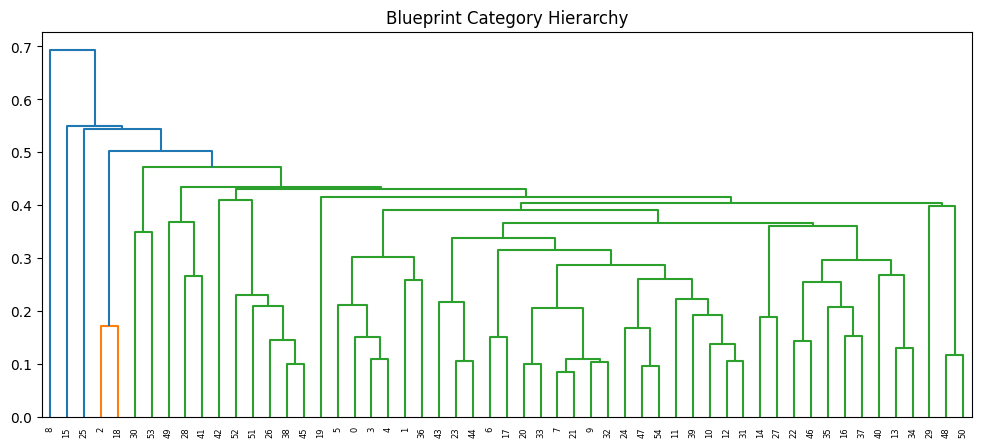

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(centroids_sorted, method="average", metric="cosine")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Blueprint Category Hierarchy")
plt.show()

In [15]:
bp_df["top_cluster"].unique().shape

(16,)

In [34]:
top_to_fine = {}
for label, idx in enumerate(top_labels):
    top_to_fine[label] = idx
top_to_fine

{0: 5,
 1: 5,
 2: 7,
 3: 5,
 4: 5,
 5: 5,
 6: 2,
 7: 2,
 8: 15,
 9: 2,
 10: 2,
 11: 2,
 12: 2,
 13: 6,
 14: 3,
 15: 11,
 16: 6,
 17: 2,
 18: 7,
 19: 8,
 20: 2,
 21: 2,
 22: 6,
 23: 2,
 24: 2,
 25: 9,
 26: 1,
 27: 3,
 28: 14,
 29: 12,
 30: 0,
 31: 2,
 32: 2,
 33: 2,
 34: 6,
 35: 6,
 36: 5,
 37: 6,
 38: 1,
 39: 2,
 40: 6,
 41: 14,
 42: 10,
 43: 2,
 44: 2,
 45: 1,
 46: 6,
 47: 2,
 48: 4,
 49: 13,
 50: 4,
 51: 1,
 52: 1,
 53: 0,
 54: 2}

In [ ]:
similarity_matrix = cosine_similarity(centroids_sorted)
threshold = 0.50
pairs = []
for i in range(similarity_matrix.shape[0]):
    for j in range(i + 1, similarity_matrix.shape[1]):
        sim = similarity_matrix[i, j]
        if sim >= threshold:
            pairs.append((i, j, sim))
            
pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
for i, j, sim in pairs:
    if top_to_fine.get(i) != top_to_fine.get(j):
        print(f"Fine clusters {i} and {j} have similarity {sim:.2f}")

Fine clusters 10 and 13 have similarity 0.85
Fine clusters 10 and 28 have similarity 0.84
Fine clusters 4 and 12 have similarity 0.83
Fine clusters 24 and 37 have similarity 0.83
Fine clusters 12 and 13 have similarity 0.83
Fine clusters 28 and 31 have similarity 0.83
Fine clusters 24 and 34 have similarity 0.82
Fine clusters 3 and 12 have similarity 0.82
Fine clusters 24 and 52 have similarity 0.81
Fine clusters 24 and 46 have similarity 0.81
Fine clusters 4 and 10 have similarity 0.80
Fine clusters 14 and 24 have similarity 0.80
Fine clusters 13 and 33 have similarity 0.80
Fine clusters 24 and 45 have similarity 0.80
Fine clusters 4 and 13 have similarity 0.80
Fine clusters 41 and 46 have similarity 0.79
Fine clusters 51 and 54 have similarity 0.79
Fine clusters 7 and 22 have similarity 0.79
Fine clusters 4 and 22 have similarity 0.79
Fine clusters 3 and 20 have similarity 0.79
Fine clusters 24 and 26 have similarity 0.79
Fine clusters 4 and 7 have similarity 0.78
Fine clusters 24 an

In [17]:
def write_to_md(filename: str):    
    with open(filename, "w", encoding="utf-8") as f:
        for cluster_id in range(agg.n_clusters_):
            f.write(f"<details>\n")
            features = analyze_cluster_features(bp_df, cluster_id=cluster_id, top_n=5)
            f.write(f"<summary> Cluster {cluster_id} </summary>\n\n")
            f.write(f"Top 5 features: \n")
            for feature, count in features:
                f.write(f"- {feature}: {count} \n")
            f.write("\n")
            fine_clusters = bp_df[bp_df["top_cluster"] == cluster_id]["fine_cluster"].unique()
            f.write(f"Sub-clusters: {', '.join(map(str, fine_clusters))} \n\n")
            for fine_cluster in fine_clusters:
                f.write(f"<details>\n")
                f.write(f"<summary> Sub-cluster {fine_cluster} </summary>\n\n")
                features = analyze_cluster_features(bp_df, fine_cluster=fine_cluster, top_n=5)
                f.write(f"Top 5 features: \n")
                for feature, count in features:
                    f.write(f"- {feature}: {count} \n")
                f.write("\n")
                bps = bp_df[(bp_df["top_cluster"] == cluster_id) & (bp_df["fine_cluster"] == fine_cluster)]
                for idx, bp in bps.iterrows():
                    post_url = topics_df[topics_df["post_id"] == bp["post_id"]]["post_url"].values[0]
                    f.write(f"- {bp['name']}, [Link]({post_url}) \n")
                f.write("\n")
                f.write(f"</details>\n\n")
            f.write(f"</details>\n\n")
c_name = "agg_clusters_d_threshold_16_2_55_fine"
write_to_md(f"output/{c_name}.md")